# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI DS Job Salaries Dataset](https://www.kaggle.com/datasets/uditjain13/ai-and-data-science-job-salaries-2026/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai_ds_job_salaries_2026.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,primary_language,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,Python,False,True,5,0,48.0,True,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,SQL,True,False,6,1,41.6,False,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,Python,True,False,4,1,55.1,True,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,Java,False,False,6,2,41.1,True,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,Python,False,False,13,2,48.2,False,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


## last Five row

In [4]:
df.tail()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,primary_language,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
4995,Data Analyst,Mid,Full-time,M,PL,PL,Finance,50,9.3,Masters,Python,False,False,11,2,40.8,False,1.5,PLN,38810,0.182,12.0,7.3,2,False,7.8,4.8
4996,Machine Learning Engineer,Lead,Full-time,M,ES,ES,Technology,0,13.3,Self-taught,R,True,True,10,1,54.7,False,2.6,EUR,123368,0.000,11.0,5.5,7,False,4.0,1.3
4997,Data Science Manager,Senior,Full-time,M,PL,PL,Technology,50,8.1,Bachelors,SQL,False,False,8,3,51.8,True,9.7,PLN,86123,0.078,13.3,7.0,6,True,19.2,2.7
4998,Research Scientist,Senior,Freelance,M,PL,PL,Technology,0,12.9,Bachelors,SQL,True,False,7,1,38.4,True,10.7,PLN,76001,0.122,10.1,6.0,4,True,10.8,1.5
4999,Business Intelligence Analyst,Entry,Contract,M,US,US,Government,0,2.1,Masters,R,False,False,6,2,34.5,True,10.4,USD,49321,0.022,4.8,6.6,3,False,6.9,6.1


## Shape of our dataset

In [5]:
df.shape

(5000, 27)

## List out all columns

In [6]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry', 'remote_ratio',
       'years_experience', 'education_level', 'primary_language',
       'has_ml_in_title', 'manages_people', 'team_size',
       'certifications_count', 'weekly_hours', 'uses_ai_tools_daily',
       'ai_tools_hours_per_week', 'salary_currency', 'salary_usd',
       'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score',
       'interviews_to_offer', 'switched_jobs_last_year',
       'upskilling_hours_per_month', 'fears_ai_automation_score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

job_title                      object
experience_level               object
employment_type                object
company_size                   object
company_location               object
employee_residence             object
industry                       object
remote_ratio                    int64
years_experience              float64
education_level                object
primary_language               object
has_ml_in_title                  bool
manages_people                   bool
team_size                       int64
certifications_count            int64
weekly_hours                  float64
uses_ai_tools_daily              bool
ai_tools_hours_per_week       float64
salary_currency                object
salary_usd                      int64
equity_offered_pct            float64
bonus_pct                     float64
job_satisfaction_score        float64
interviews_to_offer             int64
switched_jobs_last_year          bool
upskilling_hours_per_month    float64
fears_ai_aut

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   object 
 1   experience_level            5000 non-null   object 
 2   employment_type             5000 non-null   object 
 3   company_size                5000 non-null   object 
 4   company_location            5000 non-null   object 
 5   employee_residence          5000 non-null   object 
 6   industry                    5000 non-null   object 
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   object 
 10  primary_language            5000 non-null   object 
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 

## Check Null Value

In [9]:
df.isnull().sum()

job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.361440,7.93620,1.820400,44.345400,8.437400,98605.406200,0.139020,10.802720,6.685320,5.230800,8.680740,4.846080
std,41.45428,4.820808,2.64793,1.344212,6.142761,5.503637,55369.310473,0.184243,5.152959,1.364302,2.412695,4.422549,1.725924
min,0.00000,0.000000,1.00000,0.000000,24.400000,0.000000,12000.000000,0.000000,0.000000,1.100000,1.000000,0.000000,1.000000
25%,0.00000,4.800000,6.00000,1.000000,40.100000,3.300000,55592.750000,0.017000,7.100000,5.800000,3.000000,5.600000,3.700000
50%,50.00000,8.100000,8.00000,2.000000,44.400000,8.500000,90572.000000,0.072000,10.600000,6.700000,5.000000,8.700000,4.800000
75%,100.00000,11.500000,10.00000,3.000000,48.500000,12.625000,129657.750000,0.175000,14.200000,7.600000,7.000000,11.700000,6.000000
max,100.00000,23.700000,19.00000,8.000000,67.300000,25.200000,372347.000000,1.264000,30.800000,10.000000,16.000000,26.200000,10.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

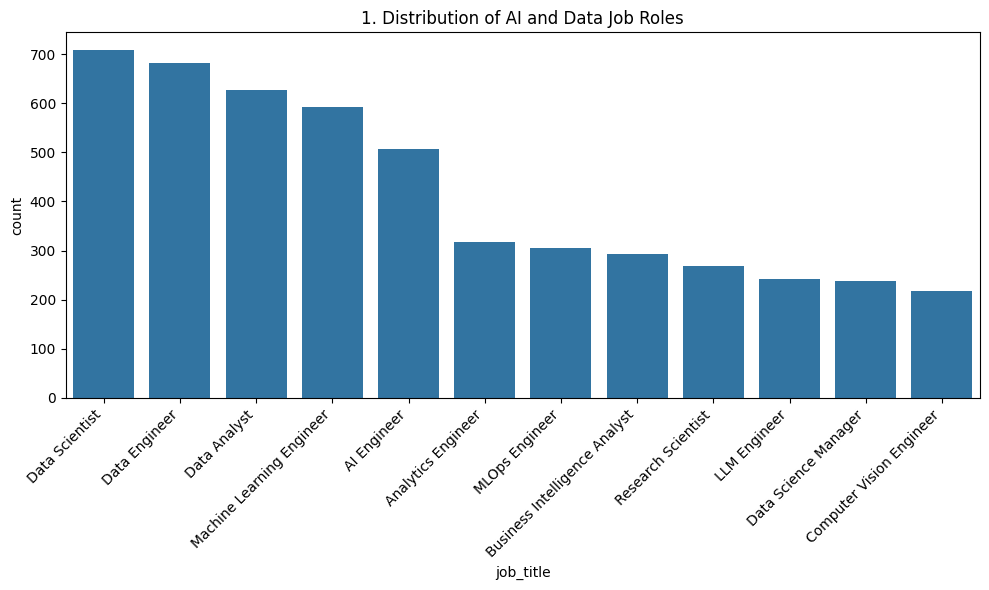

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='job_title', order=df['job_title'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title(f'{plot_no}. Distribution of AI and Data Job Roles')
show_fig()
plot_no += 1

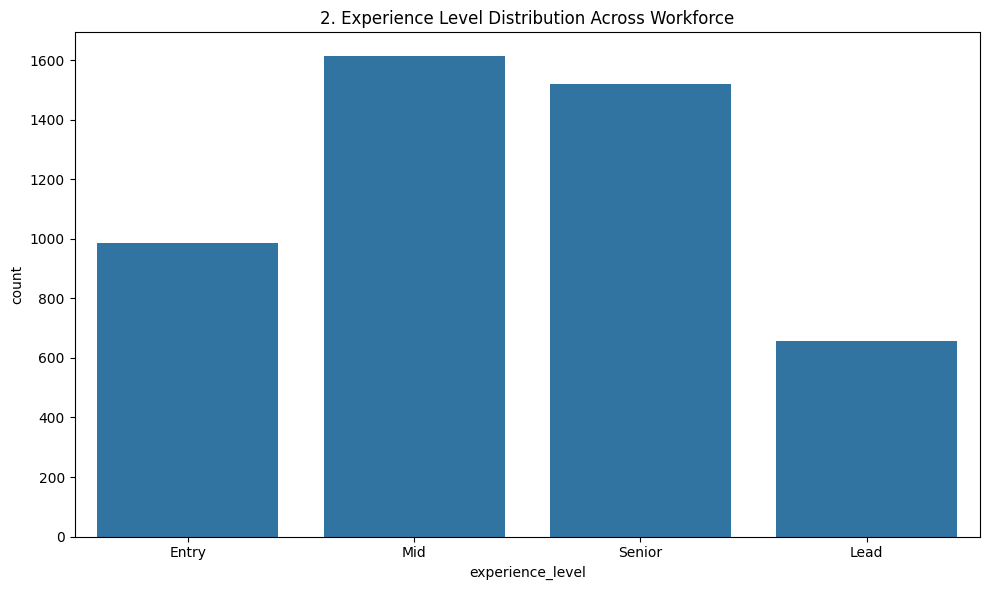

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='experience_level', order=['Entry','Mid','Senior','Lead'])
plt.title(f'{plot_no}. Experience Level Distribution Across Workforce')
show_fig()
plot_no += 1

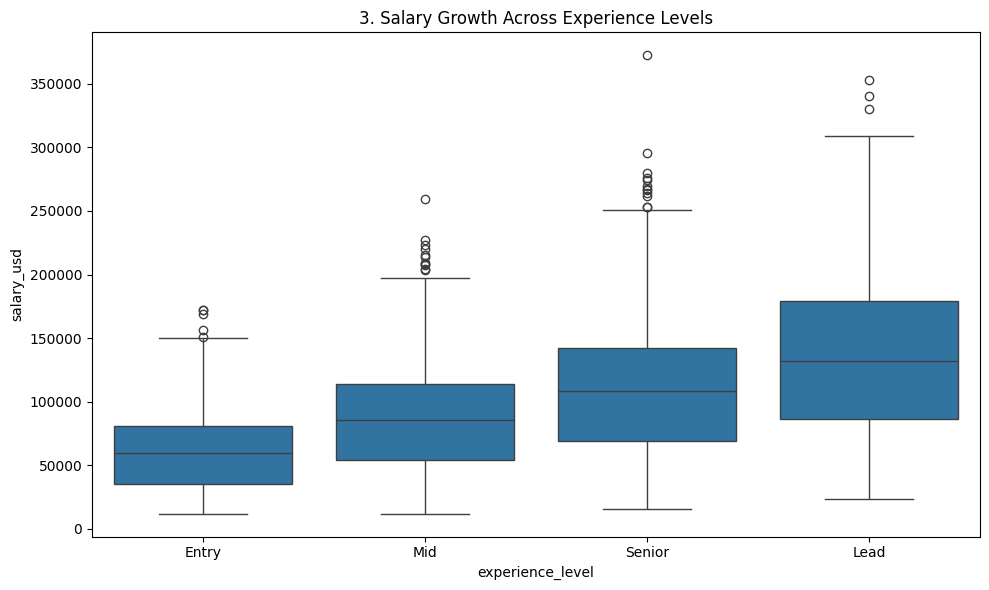

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='experience_level', y='salary_usd', order=['Entry','Mid','Senior','Lead'])
plt.title(f'{plot_no}. Salary Growth Across Experience Levels')
show_fig()
plot_no += 1

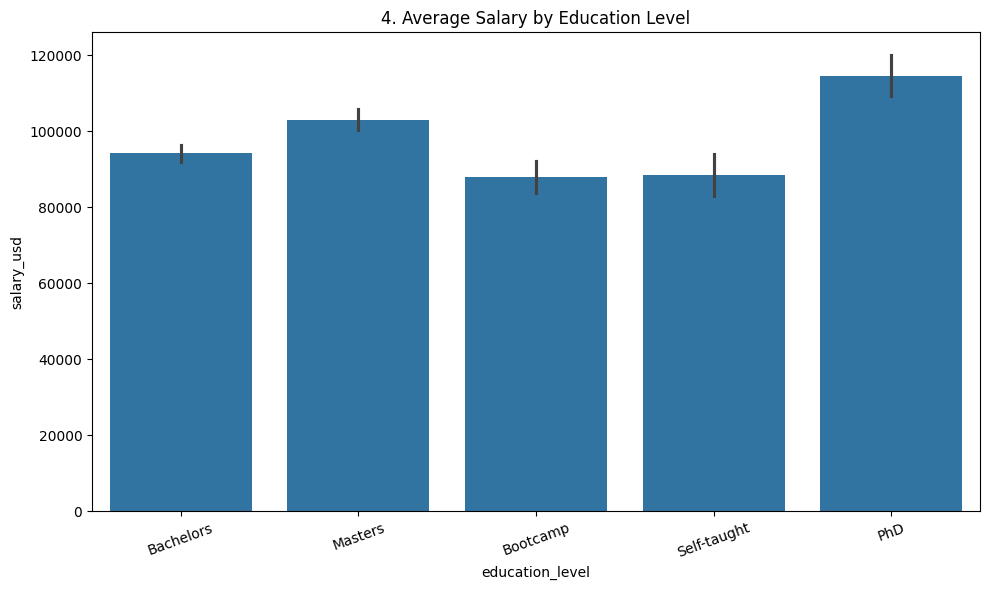

In [16]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='education_level', y='salary_usd', estimator='mean')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Average Salary by Education Level')
show_fig()
plot_no += 1

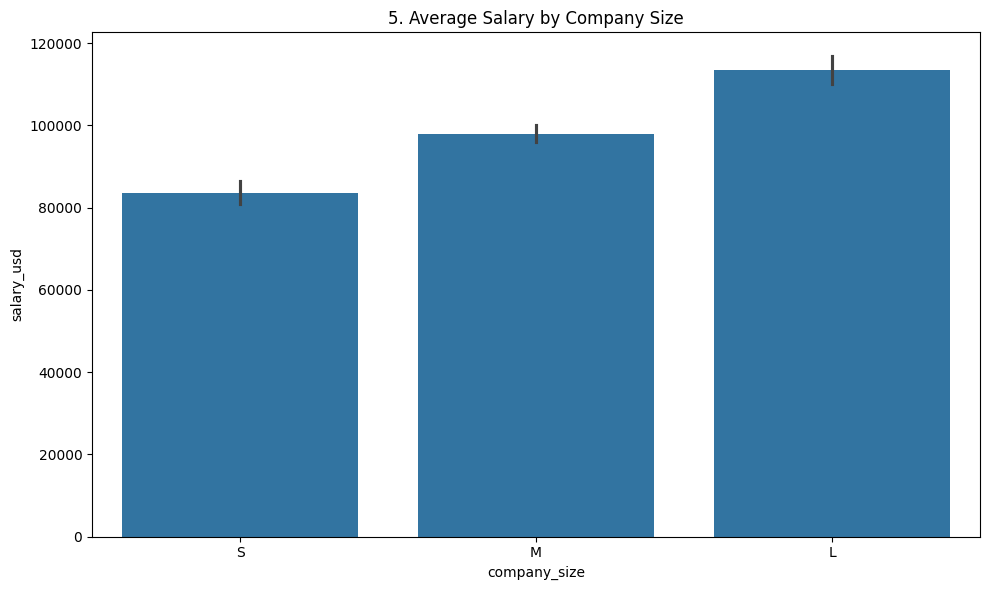

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='company_size', y='salary_usd', estimator='mean', order=['S','M','L'])
plt.title(f'{plot_no}. Average Salary by Company Size')
show_fig()
plot_no += 1

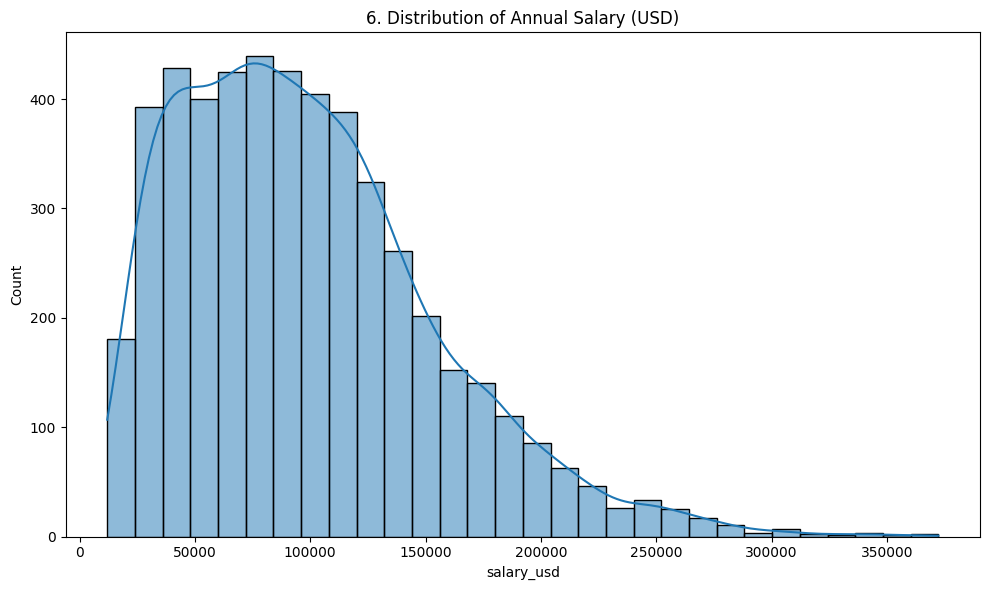

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['salary_usd'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Annual Salary (USD)')
show_fig()
plot_no += 1

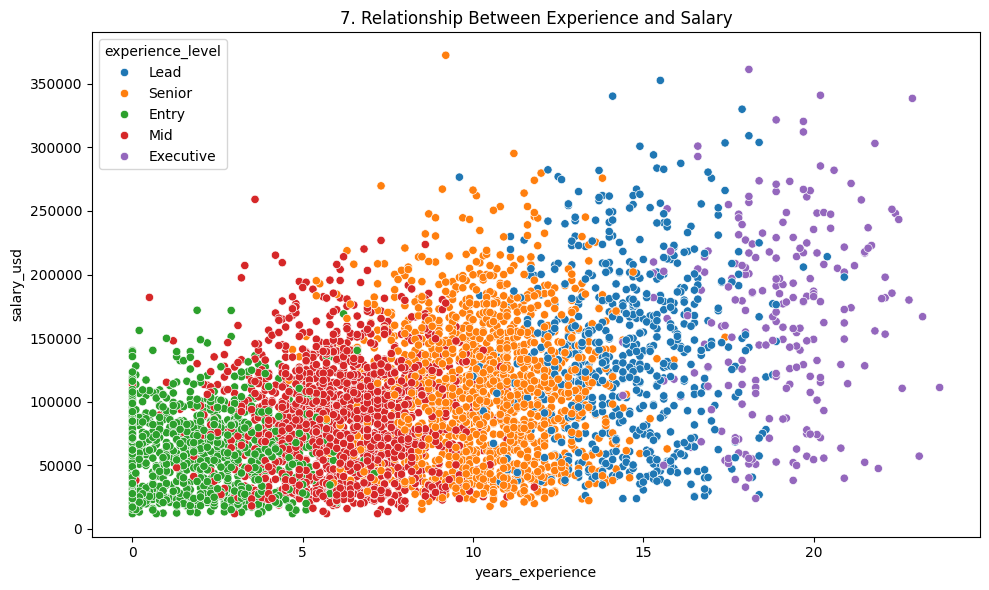

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_experience', y='salary_usd', hue='experience_level')
plt.title(f'{plot_no}. Relationship Between Experience and Salary')
show_fig()
plot_no += 1

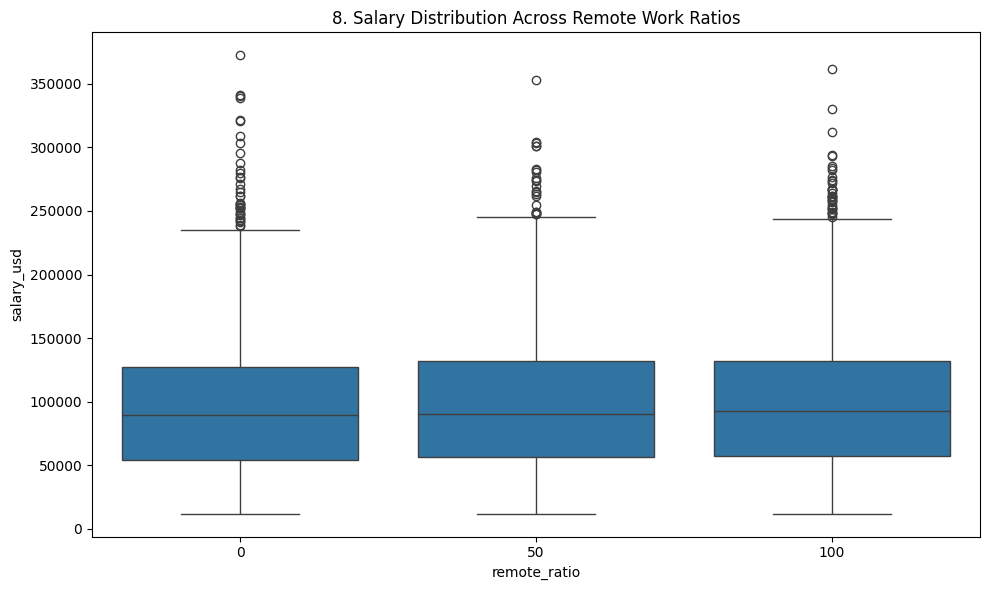

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='remote_ratio', y='salary_usd')
plt.title(f'{plot_no}. Salary Distribution Across Remote Work Ratios')
show_fig()
plot_no += 1

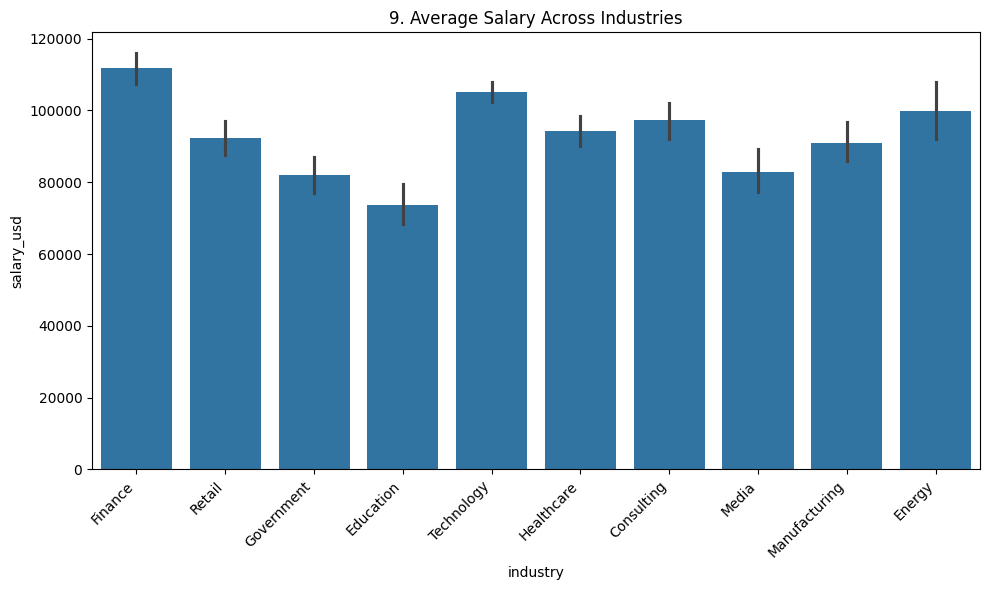

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='industry', y='salary_usd', estimator='mean')
plt.xticks(rotation=45, ha='right')
plt.title(f'{plot_no}. Average Salary Across Industries')
show_fig()
plot_no += 1

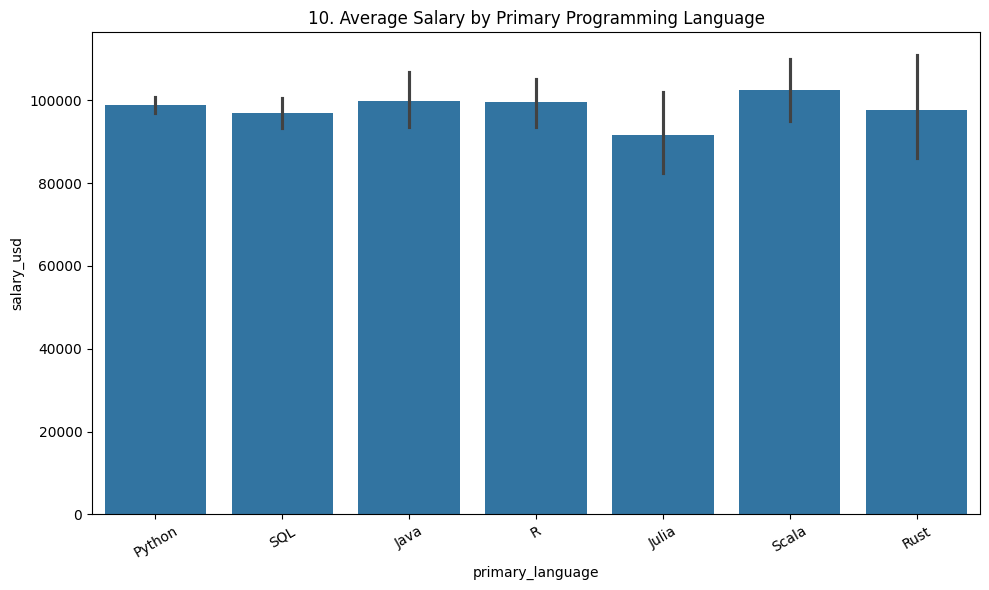

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='primary_language', y='salary_usd', estimator='mean')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Average Salary by Primary Programming Language')
show_fig()
plot_no += 1

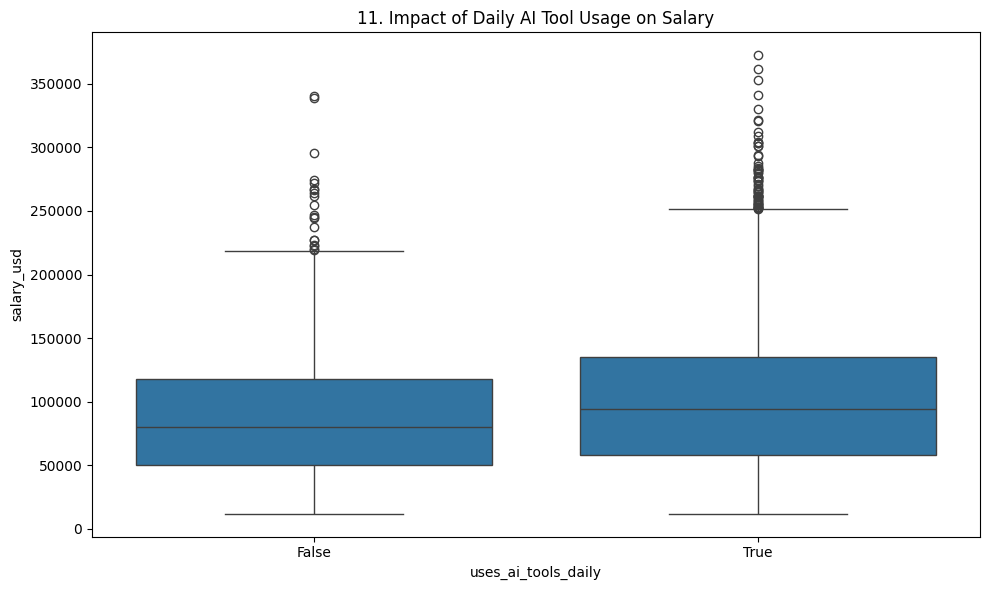

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='uses_ai_tools_daily', y='salary_usd')
plt.title(f'{plot_no}. Impact of Daily AI Tool Usage on Salary')
show_fig()
plot_no += 1

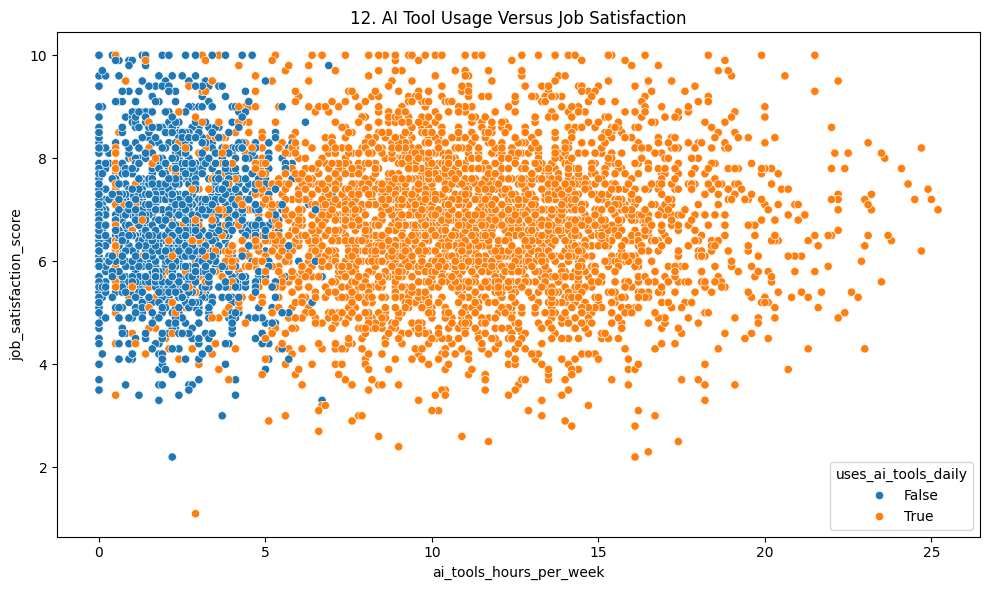

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='ai_tools_hours_per_week', y='job_satisfaction_score', hue='uses_ai_tools_daily')
plt.title(f'{plot_no}. AI Tool Usage Versus Job Satisfaction')
show_fig()
plot_no += 1

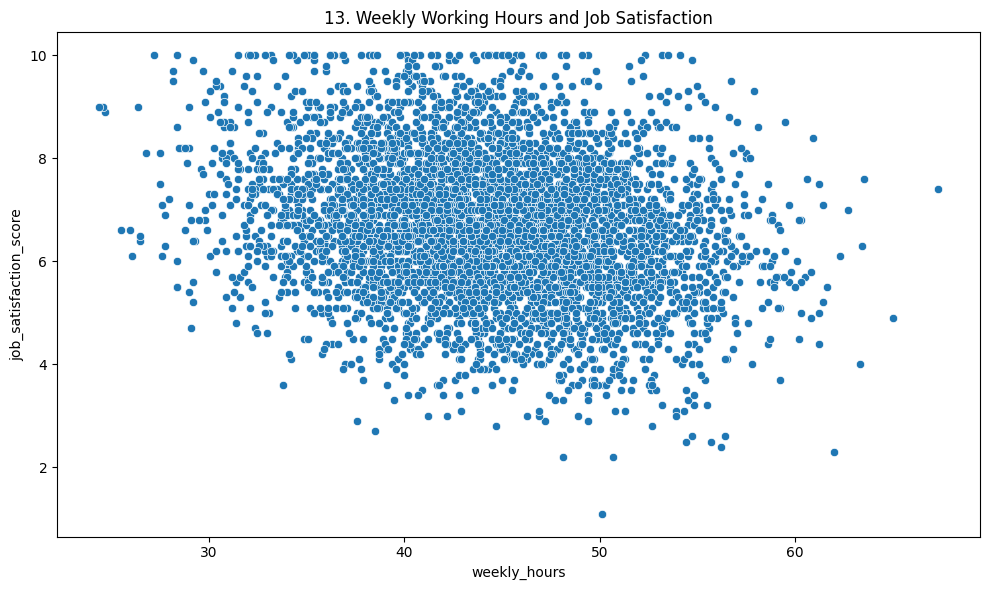

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='weekly_hours', y='job_satisfaction_score')
plt.title(f'{plot_no}. Weekly Working Hours and Job Satisfaction')
show_fig()
plot_no += 1

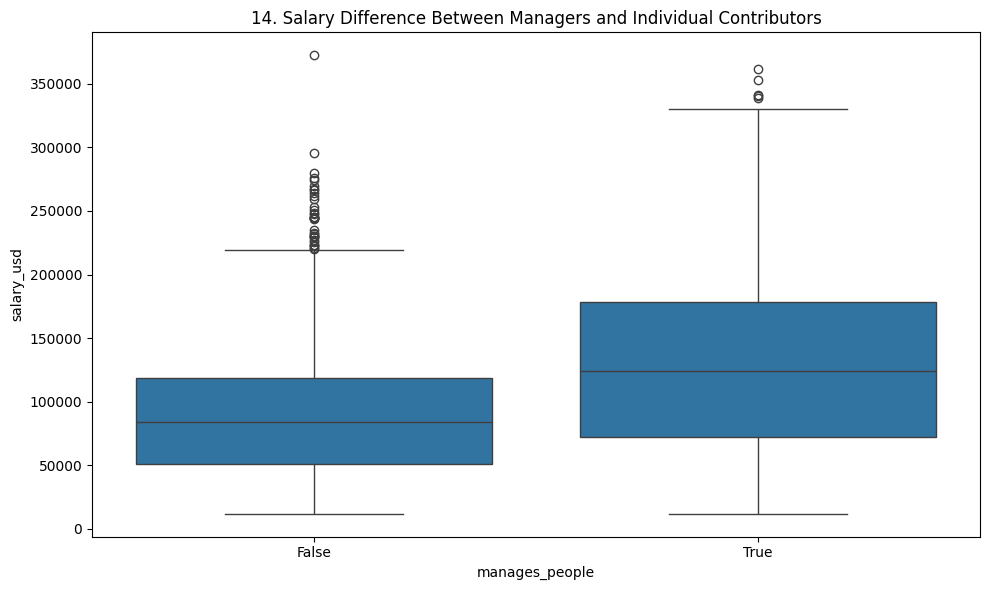

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='manages_people', y='salary_usd')
plt.title(f'{plot_no}. Salary Difference Between Managers and Individual Contributors')
show_fig()
plot_no += 1

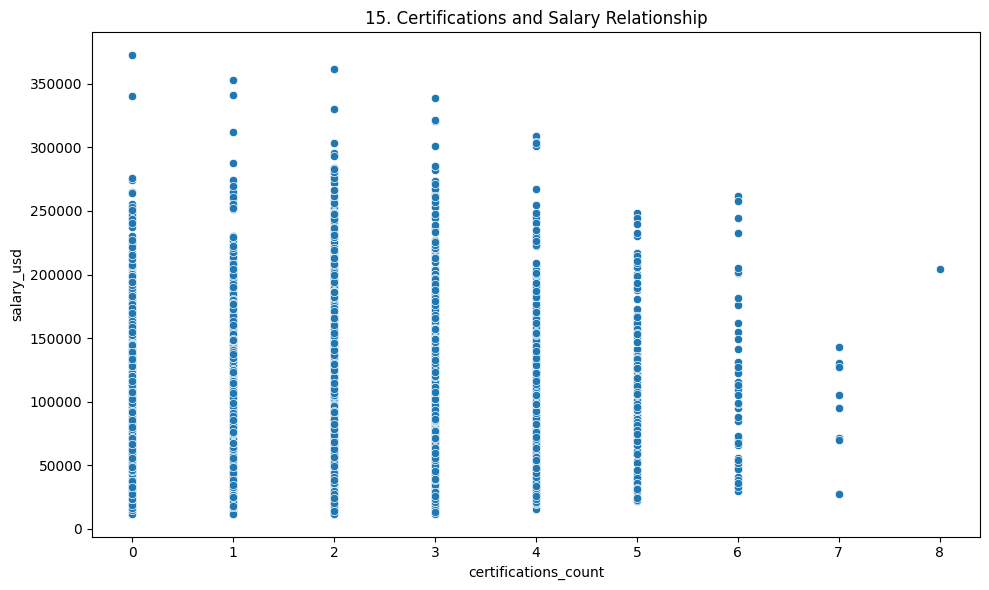

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='certifications_count', y='salary_usd')
plt.title(f'{plot_no}. Certifications and Salary Relationship')
show_fig()
plot_no += 1

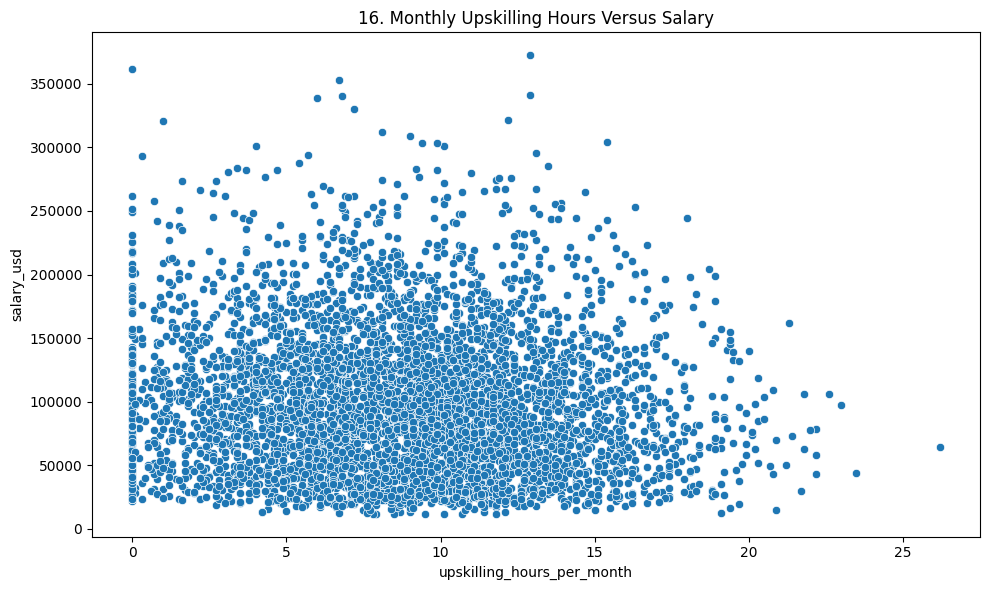

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='upskilling_hours_per_month', y='salary_usd')
plt.title(f'{plot_no}. Monthly Upskilling Hours Versus Salary')
show_fig()
plot_no += 1

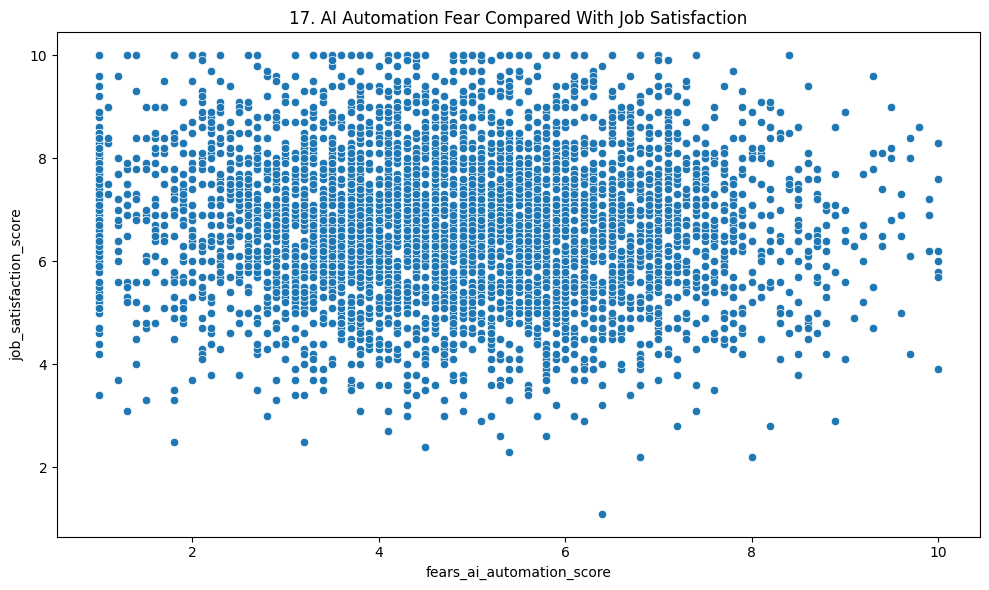

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='fears_ai_automation_score', y='job_satisfaction_score')
plt.title(f'{plot_no}. AI Automation Fear Compared With Job Satisfaction')
show_fig()
plot_no += 1

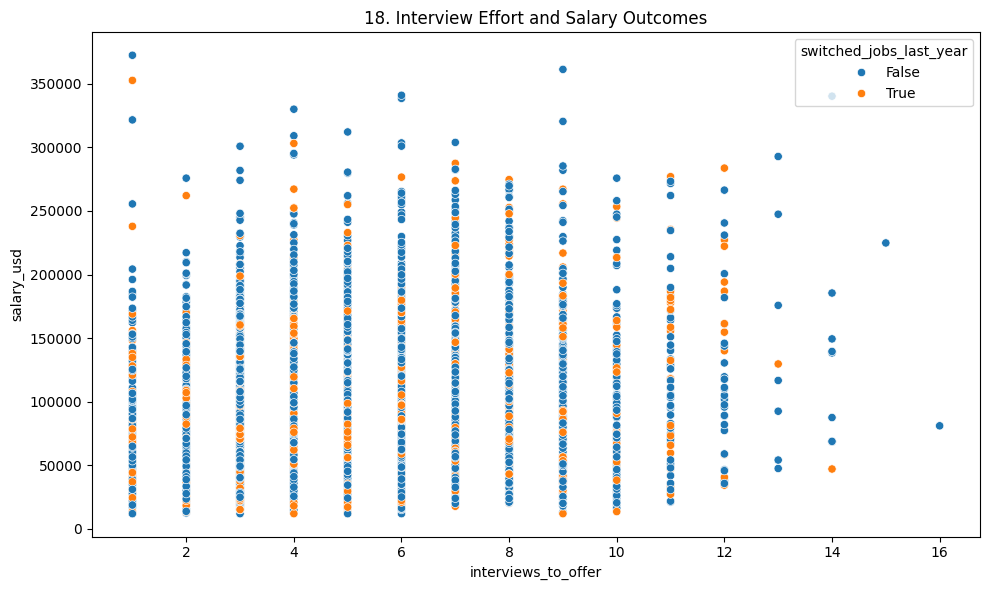

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='interviews_to_offer', y='salary_usd', hue='switched_jobs_last_year')
plt.title(f'{plot_no}. Interview Effort and Salary Outcomes')
show_fig()
plot_no += 1

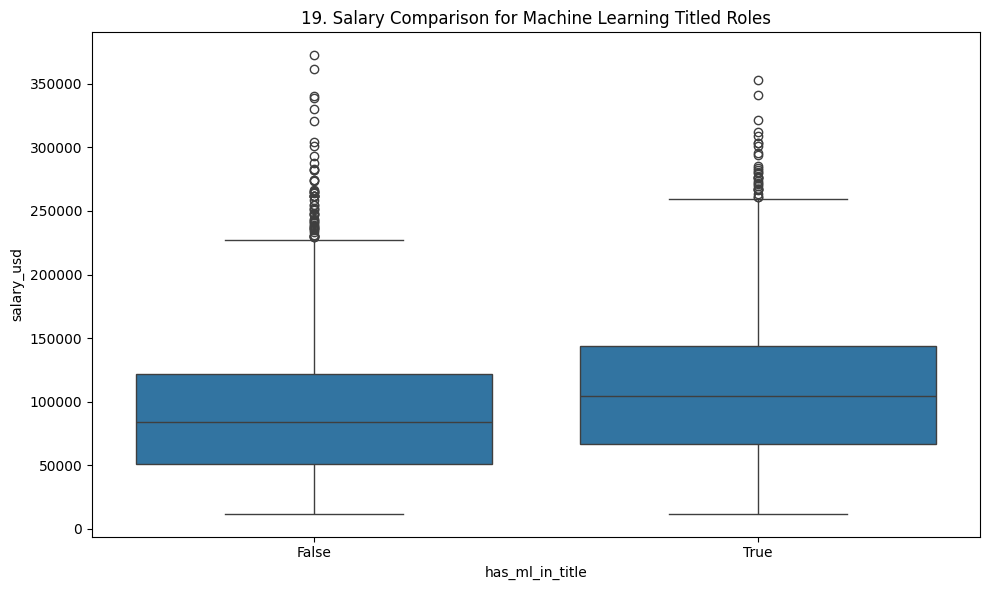

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='has_ml_in_title', y='salary_usd')
plt.title(f'{plot_no}. Salary Comparison for Machine Learning Titled Roles')
show_fig()
plot_no += 1

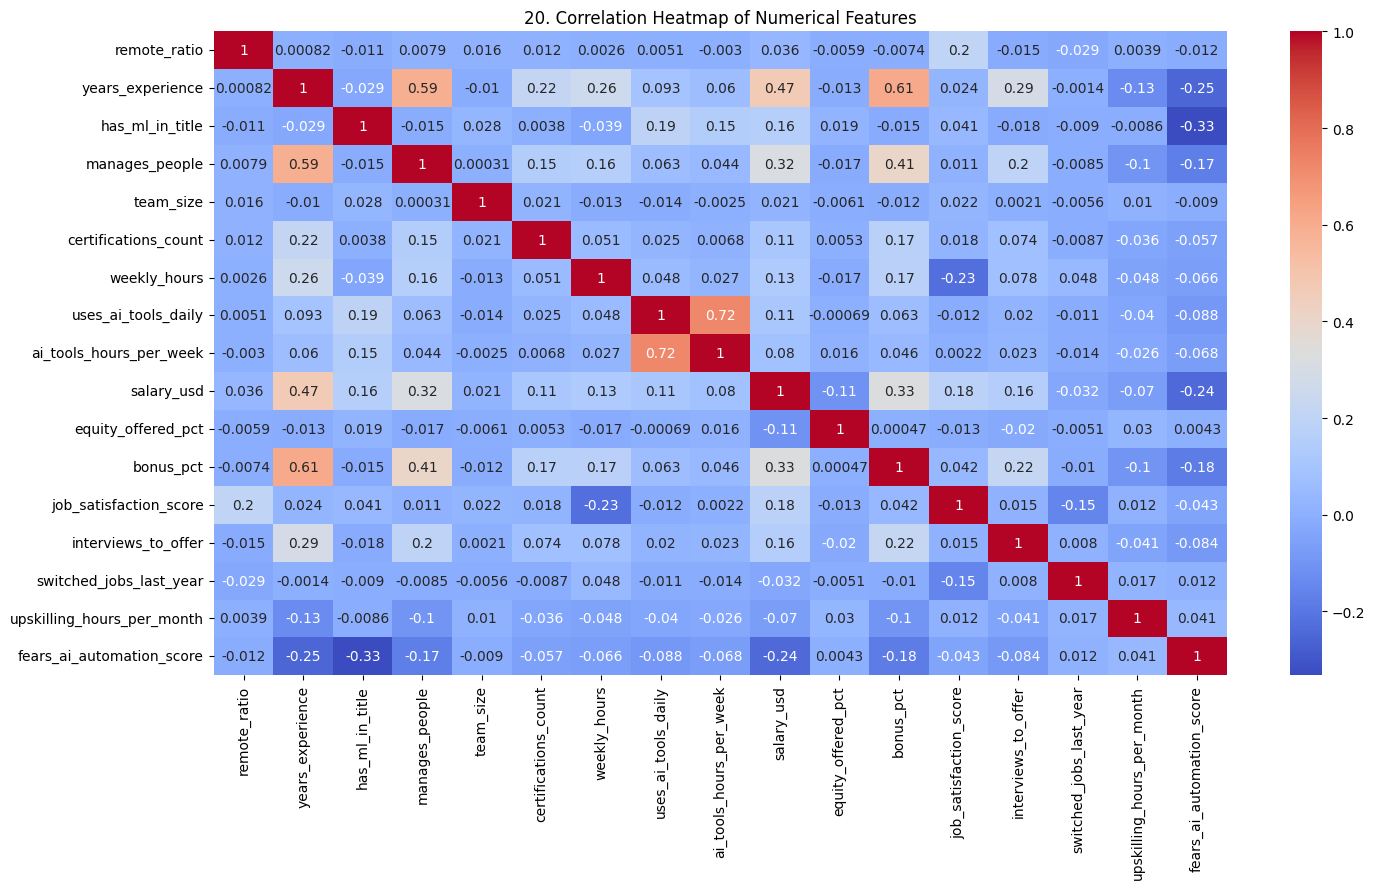

In [32]:
corr = df.corr(numeric_only=True)

fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of dataset

In [33]:
data = df.copy()

## Encode boolean columns

In [34]:
bool_cols = data.select_dtypes(include='bool').columns
for col in bool_cols:
    data[col] = data[col].astype(int)

## Define target and features

In [35]:
target = 'has_ml_in_title'
X = data.drop(columns=[target])
y = data[target]

## Identify categorical and numerical columns

In [36]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

## Build preprocessing pipeline

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', __import__('sklearn').preprocessing.OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), categorical_cols)
    ]
)

## Split dataset

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create SVM model pipeline

In [39]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

## Train model

In [40]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict test data

In [41]:
y_pred = model.predict(X_test)

## Print accuracy

In [42]:
print("Accuracy Score:", round(accuracy_score(y_test, y_pred), 4))

Accuracy Score: 0.853


## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

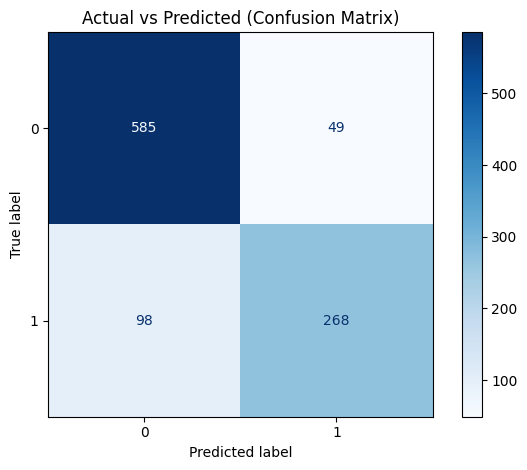

In [43]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()